# Compare different effective model potentials

In [1]:
import matplotlib.pyplot as plt

import rydstate

## Check Rubidium with large n
For Rubidium and large quantum numbers n we expect the effective model potentials to be very similar.

In [2]:
species, n, l, j = "Rb", 40, 0, 0.5
state = rydstate.RydbergStateSQDTAlkali(species, n, l=l, j=j)

states: dict[str, rydstate.RydbergStateSQDTAlkali] = {}
states["marinescu_1994"] = rydstate.RydbergStateSQDTAlkali(species, n, l=l, j=j, potential="marinescu_1994")
states["fei_2009"] = rydstate.RydbergStateSQDTAlkali(species, n, l=l, j=j, potential="fei_2009")

for label, state in states.items():
    print(f"Integrating wavefunction for {label}")
    state.radial.integrate_wavefunction()

Integrating wavefunction for marinescu_1994
Integrating wavefunction for fei_2009


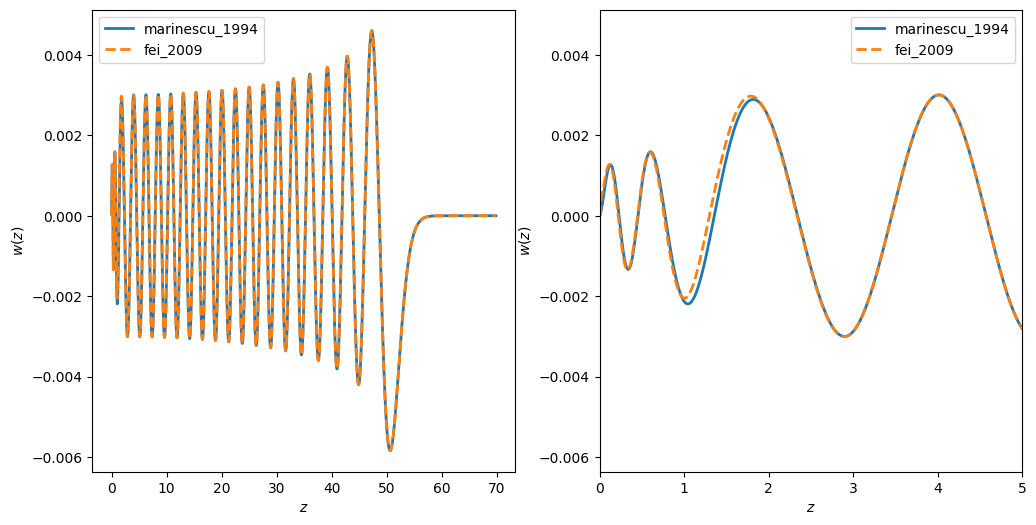

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for ax in axs:
    linestyles = ["-", "--", "-.", ":"]
    for label, state in states.items():
        ax.plot(state.radial.z_list, state.radial.w_list, label=label, lw=2, ls=linestyles.pop(0))

    ax.legend()
    ax.set_xlabel("$z$")
    ax.set_ylabel("$w(z)$")

axs[1].set_xlim(0, 5)

plt.show()

# Ions

The wavefunction for the radial_ket RadialKet(nu=2.221241487958886, potential=PotentialCoulombStrontium88Ion(l_r=0, j_r=0.5)) has some issues:
      The wavefunction has 2 nodes, but should have 4 nodes.
      The integration for l=0 did stop at 0.22 (should be close to zero).
The wavefunction for the radial_ket RadialKet(nu=2.221241487958886, potential=PotentialCorePolarizabilityWithCutoffStrontium88Ion(l_r=0, j_r=0.5)) has some issues:
      The wavefunction is not close to zero at the inner boundary (inner_weight_scaled_to_whole_grid=3.95e-02)
      The wavefunction has 2 nodes, but should have 4 nodes.
      The integration for l=0 did stop at 0.22 (should be close to zero).


Integrating wavefunction for coulomb
Integrating wavefunction for marinescu_1994
Integrating wavefunction for core_polarizability_with_cutoff


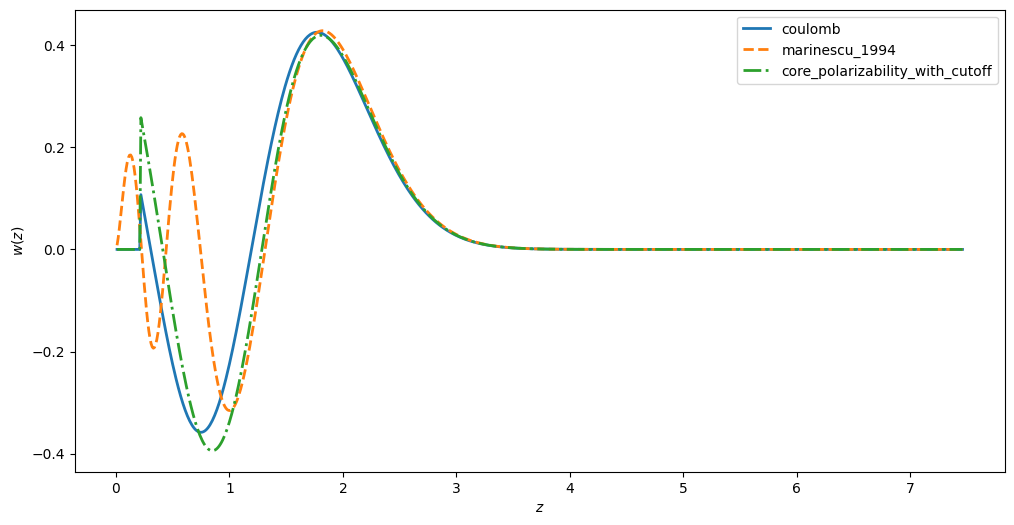

In [4]:
species, n, l, j = "Sr88_ion", 5, 0, 0.5
state = rydstate.RydbergStateSQDTAlkali(species, n, l=l, j=j)

states: dict[str, rydstate.RydbergStateSQDTAlkali] = {}
states["coulomb"] = rydstate.RydbergStateSQDTAlkali(species, n, l=l, j=j, potential="coulomb")
states["marinescu_1994"] = rydstate.RydbergStateSQDTAlkali(species, n, l=l, j=j, potential="marinescu_1994")
states["core_polarizability_with_cutoff"] = rydstate.RydbergStateSQDTAlkali(species, n, l=l, j=j, potential="core_polarizability_with_cutoff")

for label, state in states.items():
    print(f"Integrating wavefunction for {label}")
    state.radial.integrate_wavefunction()

fig, ax = plt.subplots(figsize=(12, 6))

linestyles = ["-", "--", "-.", ":"]
for label, state in states.items():
    ax.plot(state.radial.z_list, state.radial.w_list, label=label, lw=2, ls=linestyles.pop(0))

ax.legend()
ax.set_xlabel("$z$")
ax.set_ylabel("$w(z)$")


plt.show()